# Variance reduction from mixing more synthetic tasks

**Claim**: Training with more diverse synthetic tasks reduces seed-to-seed variance.

All runs are 30M-parameter llama models with `dim=512, n_layers=8, n_heads=8, head_dim=64, canon_set='', lr=3e-4`.

Groups compared (3 seeds each where available):

| Label | Tasks trained on | # tasks |
|---|---|---|
| `all_tasks` | concomp×2 + depo×2 + shortest_path×2 + bfs×2 | 8 |
| `no_depo` | concomp×2 + shortest_path×2 + bfs×2 | 6 |
| `edges_only` | concomp_el + depo_el + shortest_path_el + bfs_el | 4 |
| `depo_both` | depo_el + depo_al | 2 |
| `depo_edges` | depo_el only | 1 |

In [23]:
WANDB_API_KEY = "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"
WANDB_ENTITY  = "kirill456z"
WANDB_PROJECT = "physics4llm"

In [24]:
# One representative run per (task_group, seed).
# Using the "_2_" batch as the clean canonical version; seed 57 from the scaling-law
# runs for all_tasks (same 8-task config).
RUN_IDS = {
    # 8 tasks: concomp×2 + depo×2 + shortest_path×2 + bfs×2
    "all_tasks": [
        "depo_variance_impact_investigation_2_all_tasks_seed_55_0.4.120",  # seed 55
        "depo_variance_impact_investigation_2_all_tasks_seed_56_0.4.121",  # seed 56
        "scaling_law_4_more_seeds_llama_30m_seed_57_0.4.158",             # seed 57
    ],
    # 6 tasks: concomp×2 + shortest_path×2 + bfs×2  (depo removed)
    "no_depo": [
        "depo_variance_impact_investigation_2_no_depo_seed_54_0.4.122",   # seed 54
        "depo_variance_impact_investigation_2_no_depo_seed_55_0.4.123",   # seed 55
        "depo_variance_impact_investigation_2_no_depo_seed_56_0.4.124",   # seed 56
    ],
    # 4 tasks: edges-list format only (concomp_el + depo_el + shortest_path_el + bfs_el)
    "edges_only": [
        "seed_variance_exps_remaining_only_edges_list_55_0.4.192",        # seed 55
        "seed_variance_exps_remaining_only_edges_list_56_0.4.193",        # seed 56
        "seed_variance_exps_remaining_only_edges_list_57_0.4.194",        # seed 57
    ],
    # 2 tasks: depo_el + depo_al
    "depo_both": [
        "seed_variance_exps_remaining_only_depo_55_0.4.186",              # seed 55
        "seed_variance_exps_remaining_only_depo_56_0.4.187",              # seed 56
        "seed_variance_exps_remaining_only_depo_57_0.4.188",              # seed 57
    ],
    # 1 task: depo_el only
    "depo_edges": [
        "seed_variance_exps_remaining_only_depo_edges_55_0.4.189",        # seed 55
        "seed_variance_exps_remaining_only_depo_edges_56_0.4.190",        # seed 56
        "seed_variance_exps_remaining_only_depo_edges_57_0.4.191",        # seed 57
    ],
}

NUM_TASKS = {
    "all_tasks":  8,
    "no_depo":    6,
    "edges_only": 4,
    "depo_both":  2,
    "depo_edges": 1,
}

NICE_LABELS = {
    "all_tasks":  "All tasks (8)",
    "no_depo":    "No depo (6)",
    "edges_only": "Edges only (4)",
    "depo_both":  "Depo ×2 (2)",
    "depo_edges": "Depo edges (1)",
}

# Groups ordered from fewest to most tasks (natural reading order for variance plots)
GROUPS_ORDERED = ["depo_edges", "depo_both", "edges_only", "no_depo", "all_tasks"]

In [25]:
from utils import (
    TASK_NAMES, get_wandb_metric_keys,
    fetch_runs_results, fetch_training_history,
    plot_variance_curves, plot_final_metric_bars,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## 1. Final-step metrics: mean ± std across seeds

Fetch the wandb summary (final checkpoint values) for every run.

In [26]:
SELECTED_TASKS = TASK_NAMES
METRIC_KEYS = get_wandb_metric_keys(SELECTED_TASKS)
print(f"Fetching {len(METRIC_KEYS)} metric keys")

Fetching 25 metric keys


In [27]:
# Keep individual rows (one per seed) — do NOT average yet
results_df = fetch_runs_results(
    run_ids=RUN_IDS,
    api_key=WANDB_API_KEY,
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
)

results_df["num_tasks"]  = results_df["label"].map(NUM_TASKS)
results_df["nice_label"] = results_df["label"].map(NICE_LABELS)
results_df = results_df.sort_values("num_tasks", ascending=False).reset_index(drop=True)

print(f"\nFetched {len(results_df)} runs")
results_df[["nice_label", "num_tasks", "run_name", "loss/out"]]


[all_tasks]
  loss/out = 0.1818  (avg of last 100 steps)
  depo_variance_impact_investigation_2_all_tasks_seed_55_0.4.120  n_params=  25,444,352
  loss/out = 0.1983  (avg of last 100 steps)
  depo_variance_impact_investigation_2_all_tasks_seed_56_0.4.121  n_params=  25,444,352
  loss/out = 0.2029  (avg of last 100 steps)
  scaling_law_4_more_seeds_llama_30m_seed_57_0.4.158  n_params=  25,444,352

[no_depo]
  loss/out = 0.0583  (avg of last 100 steps)
  depo_variance_impact_investigation_2_no_depo_seed_54_0.4.122  n_params=  25,444,352
  loss/out = 0.0670  (avg of last 100 steps)
  depo_variance_impact_investigation_2_no_depo_seed_55_0.4.123  n_params=  25,444,352
  loss/out = 0.0571  (avg of last 100 steps)
  depo_variance_impact_investigation_2_no_depo_seed_56_0.4.124  n_params=  25,444,352

[edges_only]
  loss/out = 0.2025  (avg of last 100 steps)
  seed_variance_exps_remaining_only_edges_list_55_0.4.192  n_params=  25,444,352
  loss/out = 0.1836  (avg of last 100 steps)
  seed_vari

,nice_label,num_tasks,run_name,loss/out
0,All tasks (8),8,depo_variance_impact_investigation_2_all_tasks...,0.181811
1,All tasks (8),8,depo_variance_impact_investigation_2_all_tasks...,0.198312
2,All tasks (8),8,scaling_law_4_more_seeds_llama_30m_seed_57_0.4...,0.202910
3,No depo (6),6,depo_variance_impact_investigation_2_no_depo_s...,0.058341
4,No depo (6),6,depo_variance_impact_investigation_2_no_depo_s...,0.067009
5,No depo (6),6,depo_variance_impact_investigation_2_no_depo_s...,0.057060
6,Edges only (4),4,seed_variance_exps_remaining_only_edges_list_5...,0.202502
7,Edges only (4),4,seed_variance_exps_remaining_only_edges_list_5...,0.183591
8,Edges only (4),4,seed_variance_exps_remaining_only_edges_list_5...,0.211474
9,Depo ×2 (2),2,seed_variance_exps_remaining_only_depo_55_0.4.186,0.327461


### Bar chart — `loss/out` mean ± std, individual seeds overlaid

Groups ordered left → right from fewest to most tasks.

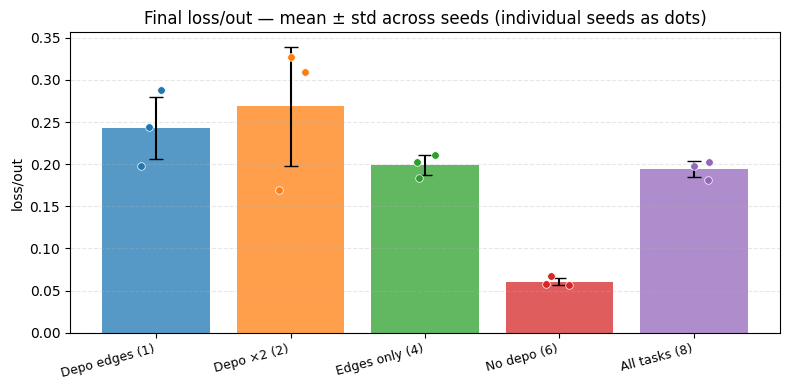

In [28]:
# Rebuild histories-style dict expected by plot_final_metric_bars:
# {group: {run_id: DataFrame(columns=["_step", metric])}}
# For final-value bars we only need one scalar per run — wrap each in a tiny 1-row DF.
from utils import fetch_training_history  # already imported; re-listed for clarity

def results_to_histories(df: pd.DataFrame, metric: str) -> dict:
    """Convert a fetch_runs_results DataFrame into the dict format plot_final_metric_bars expects."""
    out = {}
    for label in GROUPS_ORDERED:
        group_df = df[df["label"] == label]
        if group_df.empty:
            continue
        runs = {}
        for _, row in group_df.iterrows():
            val = row.get(metric, np.nan)
            runs[row["run_name"]] = pd.DataFrame({"_step": [0], metric: [val]})
        out[NICE_LABELS[label]] = runs
    return out


fig, ax = plt.subplots(figsize=(8, 4))
plot_final_metric_bars(
    results_to_histories(results_df, "loss/out"),
    metric_key="loss/out",
    ax=ax,
    title="Final loss/out — mean ± std across seeds (individual seeds as dots)",
    trailing_steps=1,  # our wrapper already stores a single final value
)
ax.set_ylabel("loss/out")
fig.tight_layout()
plt.show()

### Std across seeds — variance vs. number of tasks

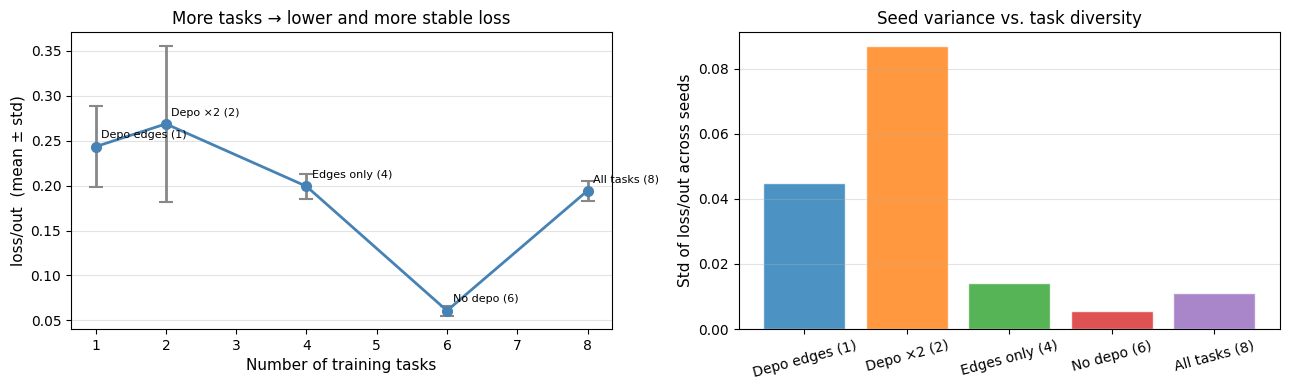

In [29]:
meta_cols = {"run_id", "run_name", "label", "nice_label", "num_tasks", "n_params"}
numeric_cols = [c for c in results_df.columns if c not in meta_cols and results_df[c].dtype != object]

group_cols = ["label", "nice_label", "num_tasks"]
mean_df = results_df.groupby(group_cols, as_index=False)[numeric_cols].mean().sort_values("num_tasks")
std_df  = results_df.groupby(group_cols, as_index=False)[numeric_cols].std(ddof=1).sort_values("num_tasks")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: mean ± std line chart
ax = axes[0]
xs   = mean_df["num_tasks"].values
ys   = mean_df["loss/out"].values
errs = std_df["loss/out"].values
ax.errorbar(xs, ys, yerr=errs, fmt="o-", capsize=5, capthick=1.5, linewidth=2,
            markersize=7, color="steelblue", ecolor="#888")
for x, y, lbl in zip(xs, ys, mean_df["nice_label"]):
    ax.annotate(lbl, xy=(x, y), xytext=(4, 6), textcoords="offset points", fontsize=8)
ax.set_xlabel("Number of training tasks", fontsize=11)
ax.set_ylabel("loss/out  (mean ± std)", fontsize=11)
ax.set_title("More tasks → lower and more stable loss")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.35)

# Right: std only (cleaner variance view)
ax = axes[1]
bar_labels = [NICE_LABELS[g] for g in GROUPS_ORDERED if g in std_df["label"].values]
bar_stds   = [std_df.loc[std_df["label"] == g, "loss/out"].iloc[0]
              for g in GROUPS_ORDERED if g in std_df["label"].values]
bar_colors = [plt.rcParams["axes.prop_cycle"].by_key()["color"][i]
              for i in range(len(bar_labels))]
ax.bar(bar_labels, bar_stds, color=bar_colors, alpha=0.8, edgecolor="white")
ax.set_ylabel("Std of loss/out across seeds", fontsize=11)
ax.set_title("Seed variance vs. task diversity")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.35)

fig.tight_layout()
plt.show()

## 2. Training curves: mean ± std band over training steps

`plot_variance_curves` draws individual seed lines (faint) plus a solid mean line with ±1 std shaded band per group.

In [30]:
# Fetch time-series history (loss/out over training steps)
histories = fetch_training_history(
    groups=RUN_IDS,
    metric_keys=["loss/out"],
    api_key=WANDB_API_KEY,
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    samples=300,
)

# 4 groups for the curve plot (no_depo excluded), ordered 1 → 8 tasks
CURVE_GROUPS = ["depo_edges", "depo_both", "edges_only", "all_tasks"]

# Red → green gradient, one colour per group (fewest tasks = red, most = green)
from matplotlib import cm as _cm, colors as _mcolors
_n = len(CURVE_GROUPS)
CURVE_PALETTE = [_mcolors.to_hex(_cm.RdYlGn(i / (_n - 1))) for i in range(_n)]

histories_nice = {NICE_LABELS[g]: histories[g] for g in CURVE_GROUPS if g in histories}
print("Groups in curve plot:", list(histories_nice.keys()))
print("Palette:", CURVE_PALETTE)


[all_tasks]
  depo_variance_impact_investigation_2_all_tasks_seed_55_0.4.120  rows=300
  depo_variance_impact_investigation_2_all_tasks_seed_56_0.4.121  rows=300
  scaling_law_4_more_seeds_llama_30m_seed_57_0.4.158       rows=300

[no_depo]
  depo_variance_impact_investigation_2_no_depo_seed_54_0.4.122  rows=300
  depo_variance_impact_investigation_2_no_depo_seed_55_0.4.123  rows=300
  depo_variance_impact_investigation_2_no_depo_seed_56_0.4.124  rows=300

[edges_only]
  seed_variance_exps_remaining_only_edges_list_55_0.4.192  rows=300
  seed_variance_exps_remaining_only_edges_list_56_0.4.193  rows=300
  seed_variance_exps_remaining_only_edges_list_57_0.4.194  rows=300

[depo_both]
  seed_variance_exps_remaining_only_depo_55_0.4.186        rows=300
  seed_variance_exps_remaining_only_depo_56_0.4.187        rows=300
  seed_variance_exps_remaining_only_depo_57_0.4.188        rows=300

[depo_edges]
  seed_variance_exps_remaining_only_depo_edges_55_0.4.189  rows=300
  seed_variance_exps_r

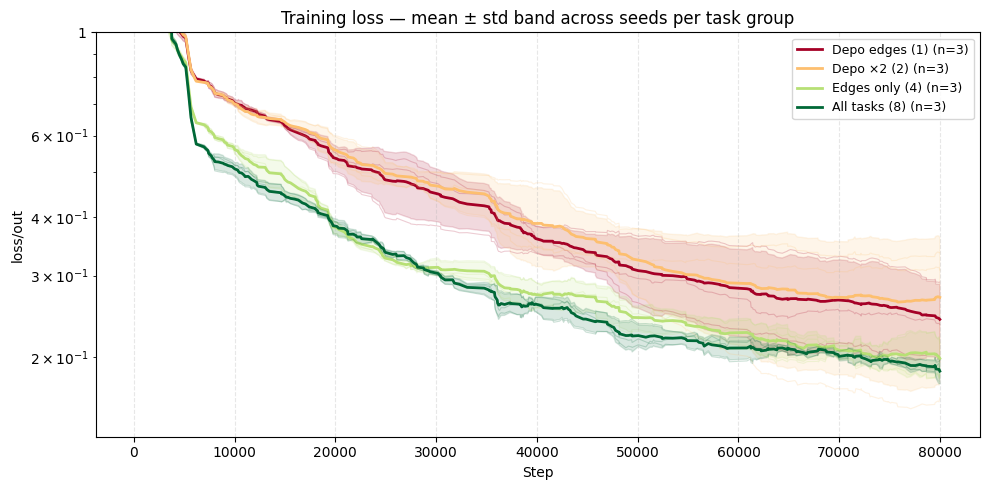

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_variance_curves(
    histories_nice,
    metric_key="loss/out",
    ax=ax,
    title="Training loss — mean ± std band across seeds per task group",
    smoothing=20,
    alpha_individual=0.2,
    show_individual=True,
    palette=CURVE_PALETTE,
)
ax.set_yscale("log")
ax.set_ylim(top=1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:g}"))
fig.tight_layout()
plt.show()

## 3. Per-task final metric breakdown

Bar charts (mean ± std, seeds as dots) for each primary metric across all groups.

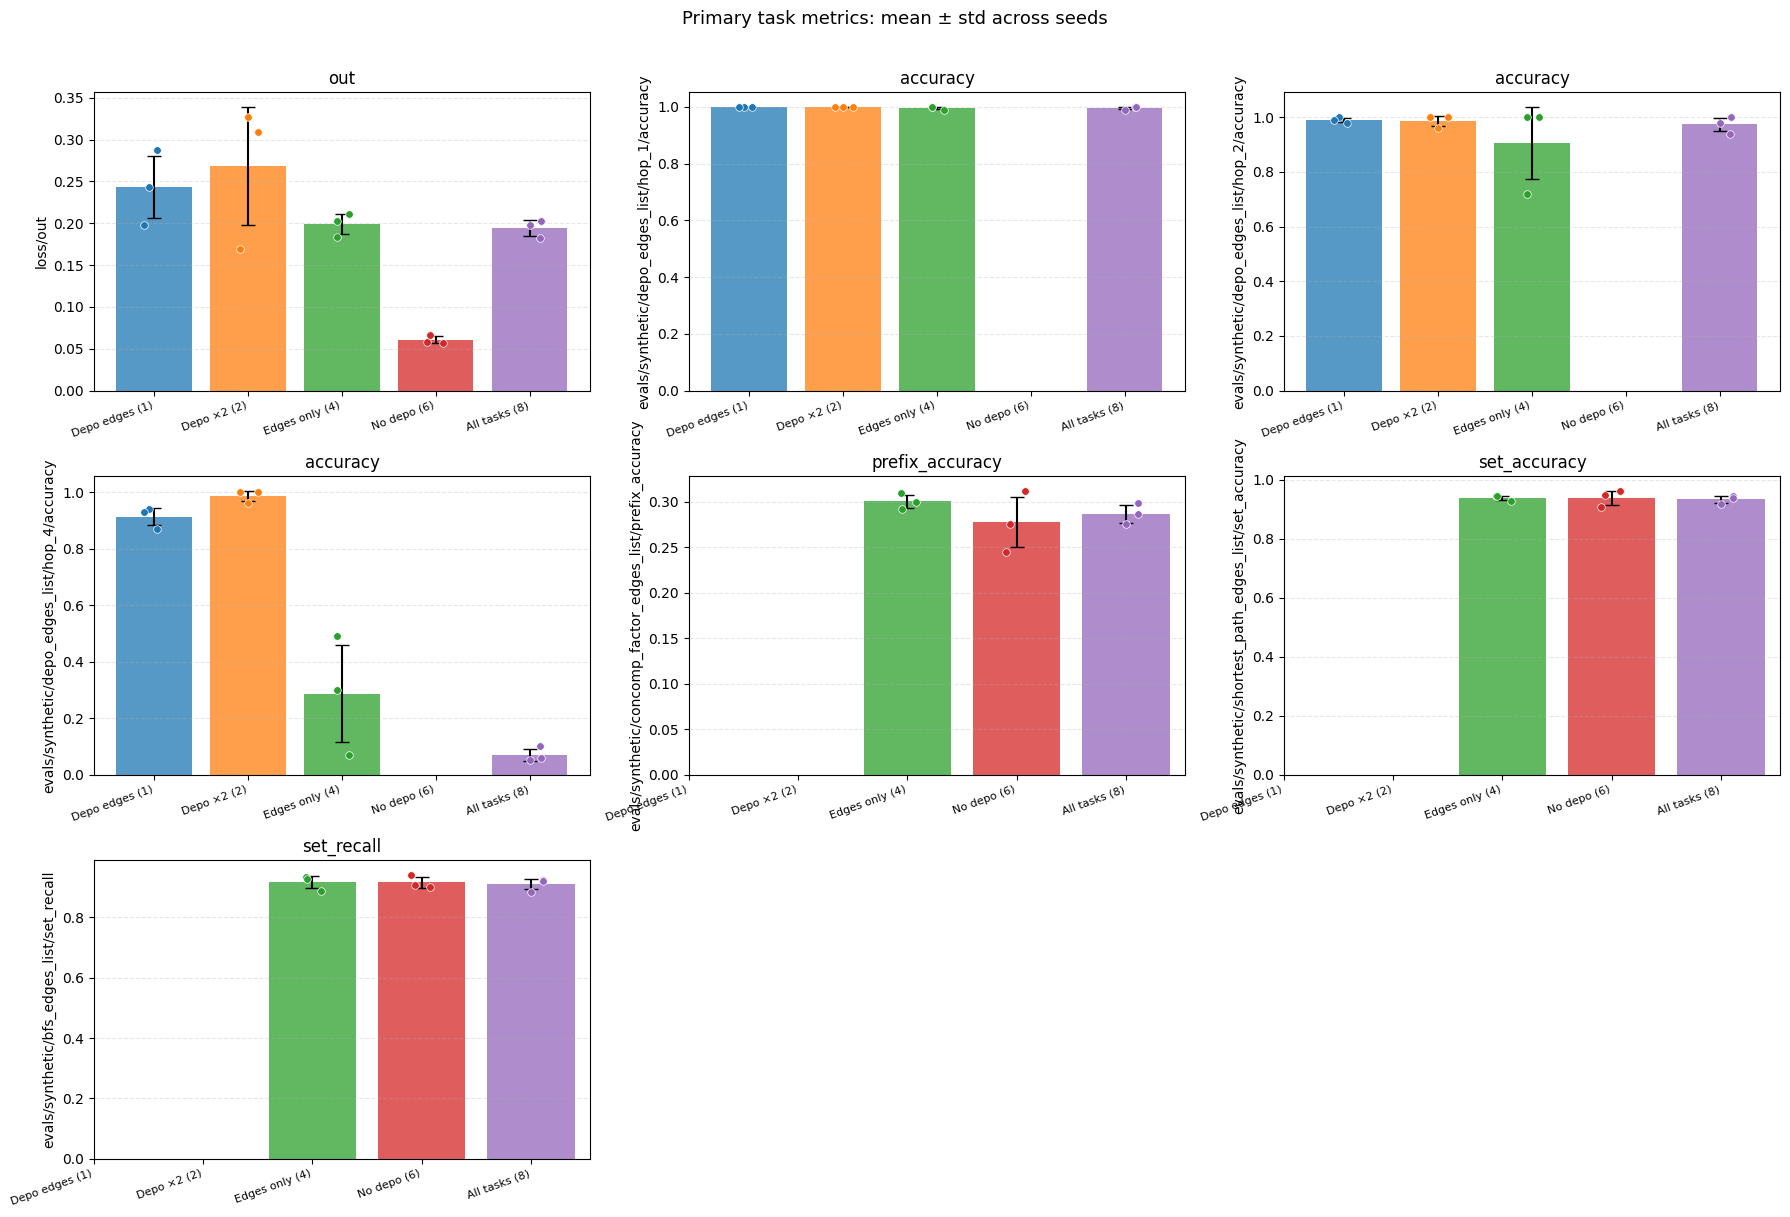

In [32]:
PRIMARY_METRICS = [
    "loss/out",
    "evals/synthetic/depo_edges_list/hop_1/accuracy",
    "evals/synthetic/depo_edges_list/hop_2/accuracy",
    "evals/synthetic/depo_edges_list/hop_4/accuracy",
    "evals/synthetic/concomp_factor_edges_list/prefix_accuracy",
    "evals/synthetic/shortest_path_edges_list/set_accuracy",
    "evals/synthetic/bfs_edges_list/set_recall",
]
PRIMARY_METRICS = [m for m in PRIMARY_METRICS if m in results_df.columns]

ncols = 3
nrows = (len(PRIMARY_METRICS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes_flat = np.array(axes).flatten()

for i, metric in enumerate(PRIMARY_METRICS):
    plot_final_metric_bars(
        results_to_histories(results_df, metric),
        metric_key=metric,
        ax=axes_flat[i],
        title=metric.split("/")[-1],
        trailing_steps=1,
    )
    axes_flat[i].tick_params(axis="x", rotation=20, labelsize=8)

for ax in axes_flat[len(PRIMARY_METRICS):]:
    ax.set_visible(False)

fig.suptitle("Primary task metrics: mean ± std across seeds", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 4. Summary table

In [22]:
rows = []
for group in GROUPS_ORDERED:
    if group not in mean_df["label"].values:
        continue
    m_row = mean_df[mean_df["label"] == group].iloc[0]
    s_row = std_df[std_df["label"]  == group].iloc[0]
    row = {"group": NICE_LABELS[group], "num_tasks": NUM_TASKS[group]}
    for m in PRIMARY_METRICS:
        if m in mean_df.columns:
            short = m.split("/")[-1]
            row[f"{short}_mean"] = round(float(m_row[m]), 4) if not pd.isna(m_row[m]) else float("nan")
            row[f"{short}_std"]  = round(float(s_row[m]), 4) if not pd.isna(s_row[m]) else float("nan")
    rows.append(row)

summary_df = pd.DataFrame(rows)
with pd.option_context("display.max_columns", 50, "display.width", 220, "display.float_format", "{:.4f}".format):
    display(summary_df)

,group,num_tasks,out_mean,out_std,accuracy_mean,accuracy_std,prefix_accuracy_mean,prefix_accuracy_std,set_accuracy_mean,set_accuracy_std,set_recall_mean,set_recall_std
0,Depo edges (1),1,0.2433,0.0448,0.9133,0.0379,NaN,NaN,NaN,NaN,NaN,NaN
1,Depo ×2 (2),2,0.2686,0.0868,0.9867,0.0231,NaN,NaN,NaN,NaN,NaN,NaN
2,Edges only (4),4,0.1992,0.0142,0.2867,0.2103,0.3005,0.0089,0.9391,0.0084,0.9160,0.0245
3,No depo (6),6,0.0608,0.0054,NaN,NaN,0.2774,0.0339,0.9396,0.0290,0.9165,0.0225
4,All tasks (8),8,0.1943,0.0111,0.0700,0.0265,0.2867,0.0120,0.9338,0.0154,0.9101,0.0210
